In [ ]:
!pip install keras --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.0.4 which is incompatible.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
from pathlib import Path
from keras import applications
from keras import layers
from keras import losses
from keras import ops
from keras import optimizers
from keras import metrics
from keras import Model


target_shape = (227, 227)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cache_dir = Path(Path.home()) / ".keras"
# anchor_images_path = cache_dir / "left"
# positive_images_path = cache_dir / "right"
anchor_images_path = Path("/content/drive/MyDrive/20K_Crack_Dataset/Anchor")
positive_images_path =Path("/content/drive/MyDrive/20K_Crack_Dataset/Positive/Positive")

In [ ]:

def preprocess_image(filename):
    """
    Load the specified file as a JPEG image, preprocess it and
    resize it to the target shape.
    """

    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    return image


def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )


In [ ]:
# We need to make sure both the anchor and positive images are loaded in
# sorted order so we can match them together.
anchor_images = sorted(
    [str(anchor_images_path / f) for f in os.listdir(anchor_images_path)]
)

positive_images = sorted(
    [str(positive_images_path / f) for f in os.listdir(positive_images_path)]
)

image_count = len(anchor_images)

anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_images)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images)

# To generate the list of negative images, let's randomize the list of
# available images and concatenate them together.
rng = np.random.RandomState(seed=42)
rng.shuffle(anchor_images)
rng.shuffle(positive_images)

negative_images = anchor_images + positive_images
np.random.RandomState(seed=32).shuffle(negative_images)

negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images)
negative_dataset = negative_dataset.shuffle(buffer_size=4096)

dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets)

# Let's now split our dataset in train and validation.
train_dataset = dataset.take(round(image_count * 0.8))
val_dataset = dataset.skip(round(image_count * 0.8))
print(len(val_dataset))
print(len(train_dataset))

train_dataset = train_dataset.batch(32, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

1683
16000


In [ ]:
len(positive_images)

17683

In [ ]:
image_count

15000

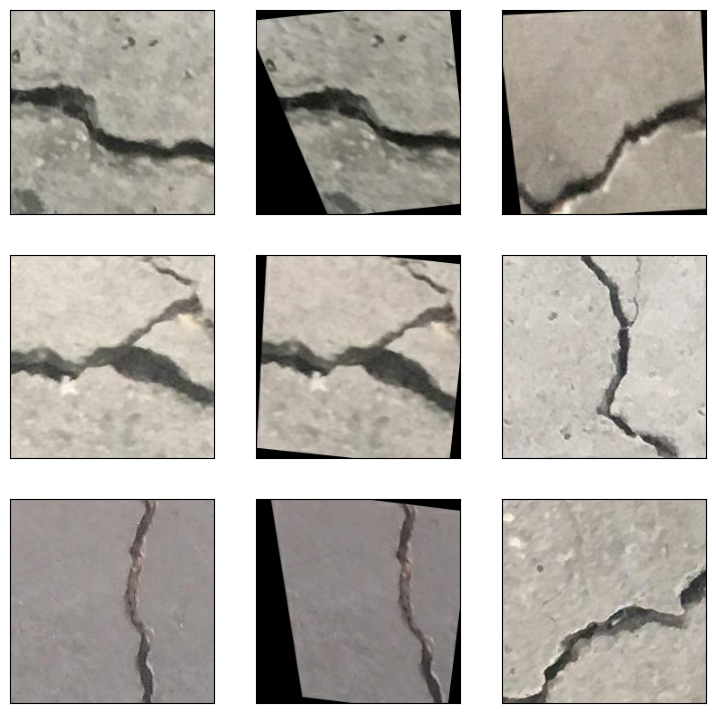

In [ ]:

def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])
# visualize(*list(val_dataset.take(1).as_numpy_iterator())[0])

In [ ]:
from keras.applications import ResNet101,resnet

base_cnn = resnet.ResNet101(
    weights="imagenet", input_shape=target_shape + (3,), include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(256, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(128, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(128)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:

class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = ops.sum(tf.square(anchor - positive), -1)
        an_distance = ops.sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

# distances = DistanceLayer()(
#     embedding(anchor_input),
#     embedding(positive_input),
#     embedding(negative_input),
# )
distances = DistanceLayer()(
    embedding(resnet.preprocess_input(anchor_input)),
    embedding(resnet.preprocess_input(positive_input)),
    embedding(resnet.preprocess_input(negative_input)),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

NameError: name 'embedding' is not defined

In [ ]:
class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.1):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]

In [ ]:
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(optimizer=optimizers.Adam(0.0001, epsilon=1e-01))
siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ functional_1 (Functional)          │ ?                             │  76,263,808 │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 76,263,808 (290.92 MB)

 Trainable params: 42,536,192 (162.26 MB)

 Non-trainable params: 33,727,616 (128.66 MB)

In [ ]:
history=siamese_model.fit(train_dataset, epochs=200, validation_data=val_dataset,
                          # steps_per_epoch=16000//32,
                          # validation_steps=4000//32
                          )

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1763s 5s/step - loss: 0.0441 - val_loss: 0.0058
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 267ms/step - loss: 0.0062 - val_loss: 0.0041
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 265ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 268ms/step - loss: 0.0033 - val_loss: 0.0071
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 266ms/step - loss: 0.0033 - val_loss: 0.0041
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 267ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 267ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 267ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 9/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 10/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 273ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 11/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 101s 268ms/step - loss: 0.0022 - val_loss: 0.0017

In [ ]:
siamese_model.save('/content/drive/MyDrive/siamese/siamese_model7.keras')
embedding.save('/content/drive/MyDrive/siamese/embedding7.keras')

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_api.py:100: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  saving_lib.save_model(model, filepath)


In [ ]:
import matplotlib.pyplot as plt
# Plotting the training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


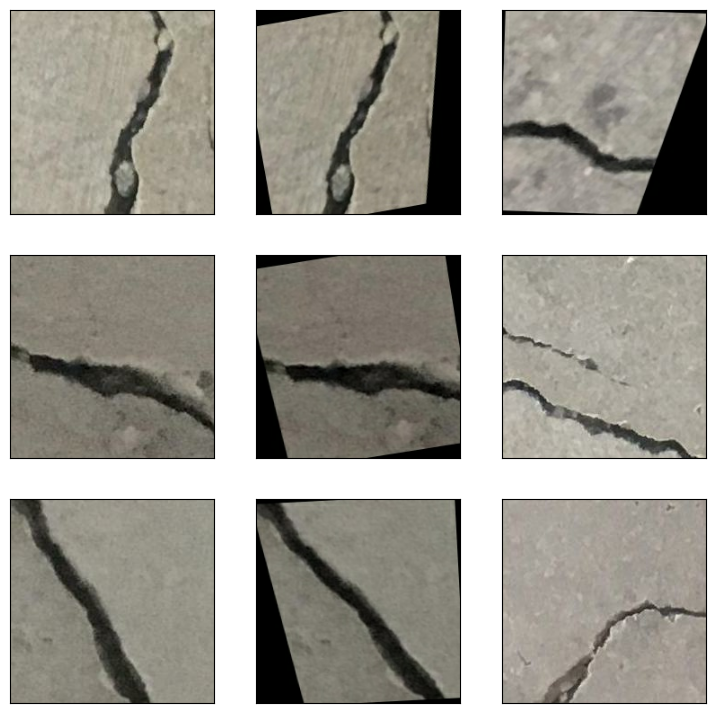

In [ ]:
from keras.applications import resnet

import keras
sample = next(iter(train_dataset))
visualize(*sample)

# anchor, positive, negative = sample
# anchor_embedding, positive_embedding, negative_embedding = (
#     embedding(anchor),
#     embedding(positive),
#     embedding(negative),
# )

# embedding = keras.saving.load_model("/content/drive/MyDrive/siamese/embedding6.keras")


anchor, positive, negative = sample
anchor_embedding, positive_embedding, negative_embedding = (
    embedding(resnet.preprocess_input(anchor)),
    embedding(resnet.preprocess_input(positive)),
    embedding(resnet.preprocess_input(negative)),
)

In [ ]:
cosine_similarity = metrics.CosineSimilarity()

positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())

negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity", negative_similarity.numpy())


Positive similarity: 0.9997395
Negative similarity 0.99794817


In [ ]:
import numpy as np
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity

# Euclidean Distance
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Manhattan Distance
def manhattan_distance(a, b):
    return np.abs(a - b).sum()

# Minkowski Distance
def minkowski_distance(a, b, p):
    return np.power(np.sum(np.abs(a - b) ** p), 1 / p)

# Hamming Distance
def hamming_distance(a, b):
    return (a != b).sum()

# Jaccard Similarity
def jaccard_similarity(a, b):
    intersection = len(set(a).intersection(set(b)))
    union = len(set(a).union(set(b)))
    return intersection / union

# Mahalanobis Distance
def mahalanobis_distance(a, b, VI):
    return distance.mahalanobis(a, b, VI)

# Correlation
def correlation(a, b):
    return np.corrcoef(a, b)[0, 1]

# Bhattacharyya Distance
def bhattacharyya_distance(a, b):
    return -np.log(np.sum(np.sqrt(a * b)))


In [ ]:
positive_manhattan_distance = manhattan_distance(anchor_embedding, positive_embedding)
print("Positive manhattan distance:", positive_manhattan_distance)

negative_manhattan_distance = manhattan_distance(anchor_embedding, negative_embedding)
print("Negative manhattan distance", negative_manhattan_distance)

NameError: name 'correlation' is not defined